In [ ]:
import xarray as xr
import numpy as np
import functions
import matplotlib.pyplot as plt
import cmcrameri

In [2]:
datadir = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/other_cloud_vars/'

## Regrid vertical variables to pressure levels

### Hybrid sigma coordinates at midpoints

In [ ]:
savedir = datadir+'regridded_midpoint_last30yrs/'
exp = 'abrupt-4xCO2'
tslice = slice('2040-01-01', '2069-12-31')
#var_list = ['CLOUD', 'RELHUM', 'Q', 'T']
var_list = ['U','V','OMEGA']
regrid_vars = ['hyam', 'hybm', 'PS', 'P0']

files = []
for var in var_list+regrid_vars:
    files.append(datadir+var+'_'+exp+'.nc')
ds_i = xr.open_mfdataset(files)

ds_slice = ds_i.sel(time=tslice)

# Regrid timesliced data
for var in var_list:
    var_da = functions.regrid_to_pressure(ds_slice,var)
    ds_slice[var] = var_da[var]

ds_slice = ds_slice.drop_vars(['hyam', 'hybm', 'P0', 'PS','lev'])
print(ds_slice)
ds_slice.to_netcdf(savedir+exp+'.nc')

## Open variables for analysis

In [34]:
filedir = datadir+'regridded_midpoint_last30yrs/'
exp_list = ['piClim', 'abrupt-4xCO2']
Arctic_lim = 60

ds_list = []
for exp in exp_list:
    files = filedir+exp+'.nc'
    ds_i = xr.open_dataset(files)
    ds_list.append(ds_i.sel(lat=slice(Arctic_lim, 90)))

ds = xr.concat(ds_list, dim='co2_conc')
ds = ds.assign_coords({'co2_conc':exp_list})

## Create regional masks

In [36]:
landmask = xr.open_dataarray(datadir+'LANDFRAC_piClim.nc')
landmask = landmask.isel(time=0)
oceanmask = 1-landmask
landmask = landmask > 0.9

## Create seasonal means

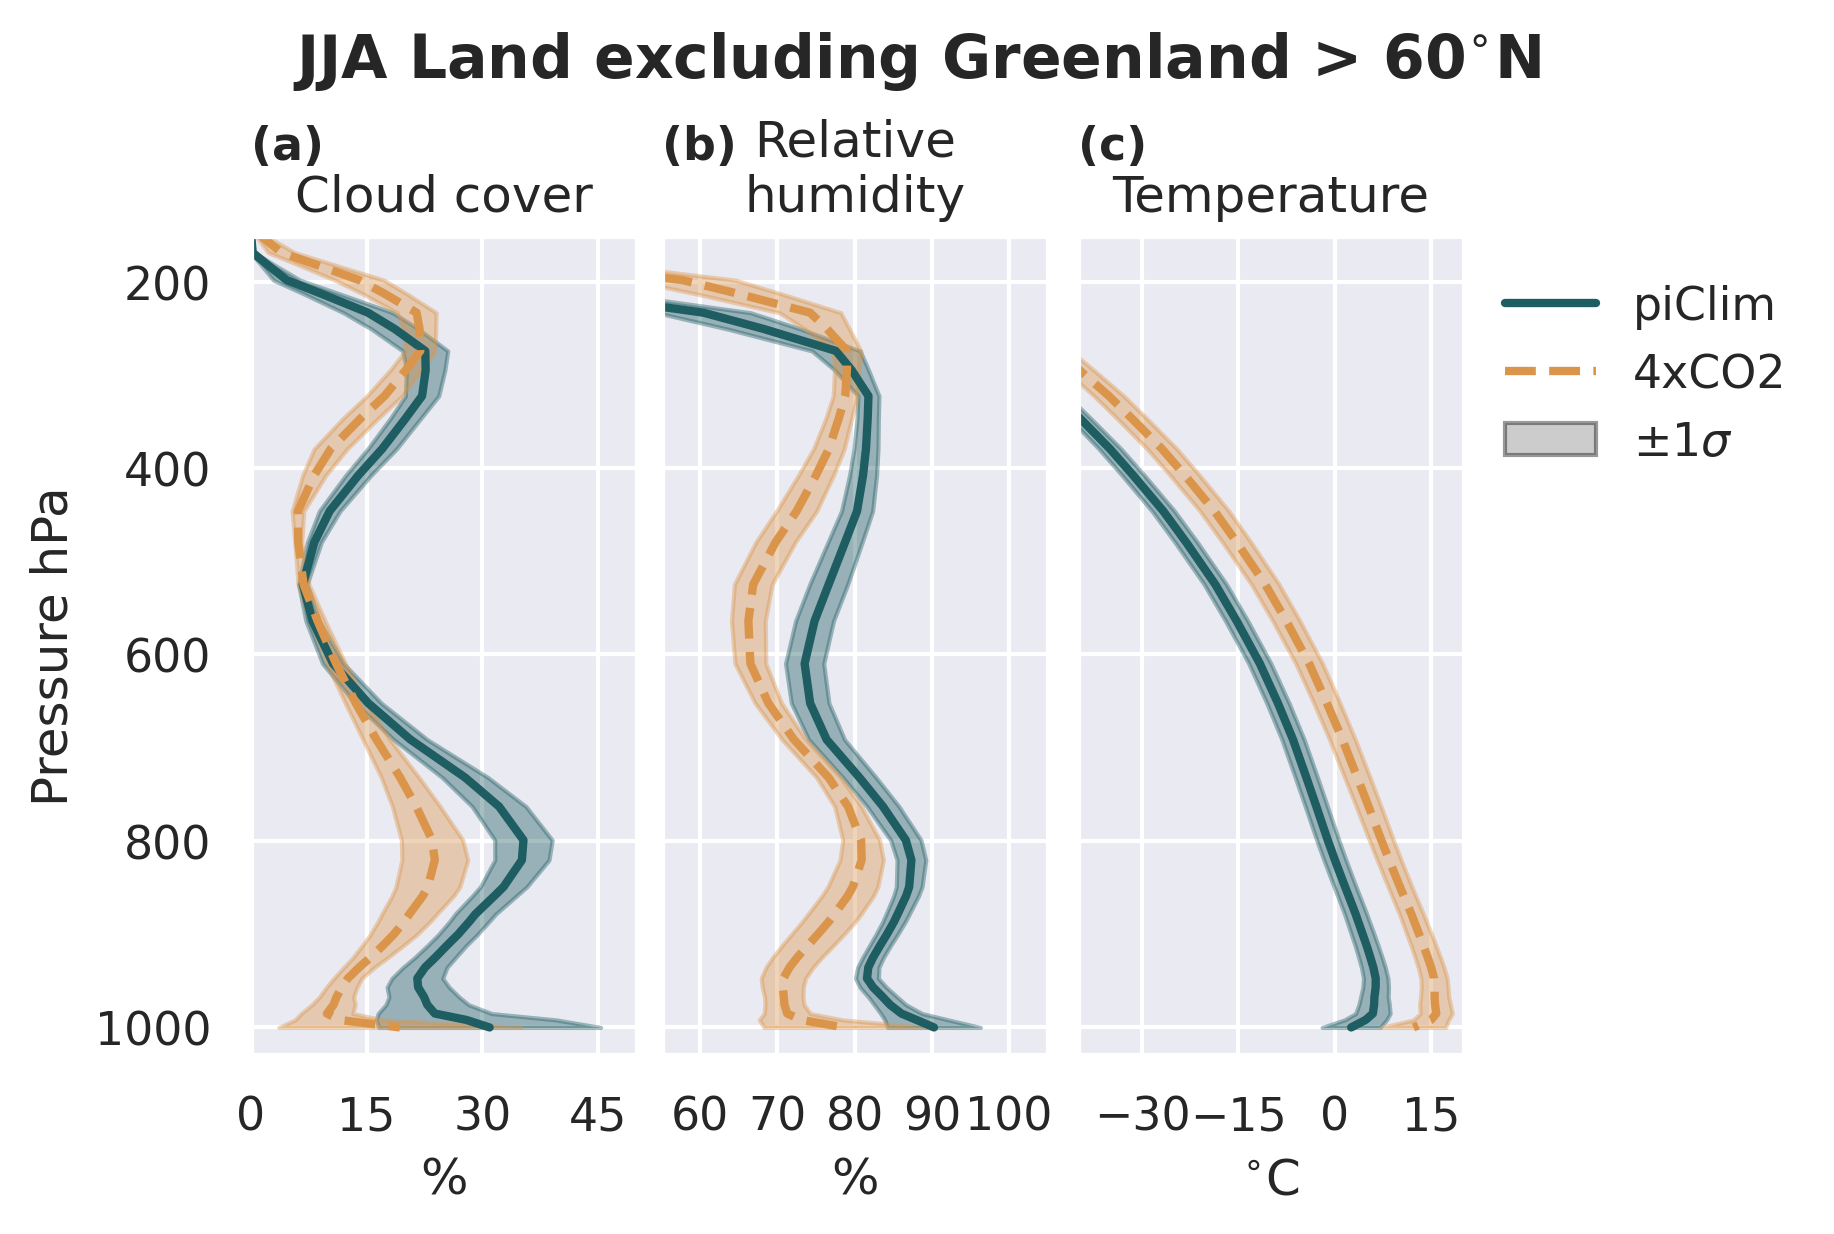

In [ ]:
import seaborn as sns
sns.set_theme()

season = 'JJA'
Arctic_limit = 60
lons=slice(0,300)
linestyles = ['-','--']
colors = [cmcrameri.cm.batlow.colors[60],cmcrameri.cm.batlow.colors[175]]
vars = ['CLOUD','RELHUM','T']
xlims = [[0,50], [55,105], [-40,20]]
names = ['Cloud cover', 'Relative\nhumidity', 'Temperature']
units = ['%', '%', '$^{\circ}$C']

labels = [['(a)','(b)','(c)']]
fig, axs = plt.subplot_mosaic(mosaic=labels, figsize=(6, 4),sharey=True, dpi=300,constrained_layout=True)
#fig, axs = plt.subplots(2, 3, figsize=(6,8), sharey=True, constrained_layout=True)
fig.suptitle(season+' Land excluding Greenland > '+str(Arctic_limit)+'$^{\circ}$N', fontweight='bold')

for i, var, xlim, name, unit in zip(range(3),vars, xlims, names, units):

    label = labels[0][i]
    

    Arctic_lnd_piClim = functions.computeWeightedMeanMasked(ds[var].sel(lat=slice(Arctic_limit, 90), lon=lons, co2_conc='piClim'), landmask.sel(lat=slice(Arctic_limit, 90), lon=lons))
    Arctic_lnd_4xCO2 = functions.computeWeightedMeanMasked(ds[var].sel(lat=slice(Arctic_limit, 90), lon=lons, co2_conc='abrupt-4xCO2'), landmask.sel(lat=slice(Arctic_limit, 90), lon=lons))
    
    Arctic_lnd_piClim_mean = Arctic_lnd_piClim.sel(time=Arctic_lnd_piClim.time.dt.season==season).mean('time')
    Arctic_lnd_piClim_std = Arctic_lnd_piClim.sel(time=Arctic_lnd_piClim.time.dt.season==season).std('time')
    
    Arctic_lnd_4xCO2_mean = Arctic_lnd_4xCO2.sel(time=Arctic_lnd_4xCO2.time.dt.season==season).mean('time')
    Arctic_lnd_4xCO2_std = Arctic_lnd_4xCO2.sel(time=Arctic_lnd_4xCO2.time.dt.season==season).std('time')
    
    if var=='CLOUD':
        axs[label].plot((Arctic_lnd_piClim_mean)*100, ds.plev, color=colors[0],linestyle = linestyles[0], lw=2)
        axs[label].plot((Arctic_lnd_4xCO2_mean)*100, ds.plev,color=colors[1], linestyle = linestyles[1], lw=2)
        axs[label].fill_betweenx(ds.plev,(Arctic_lnd_piClim_mean-Arctic_lnd_piClim_std)*100, (Arctic_lnd_piClim_mean+Arctic_lnd_piClim_std)*100, color=colors[0], alpha=0.4)
        axs[label].fill_betweenx(ds.plev,(Arctic_lnd_4xCO2_mean-Arctic_lnd_4xCO2_std)*100, (Arctic_lnd_4xCO2_mean+Arctic_lnd_4xCO2_std)*100, color=colors[1], alpha=0.4)
        
        
        axs[label].set_xticks([0, 15, 30, 45])

    elif var=='RELHUM':
        axs[label].plot((Arctic_lnd_piClim_mean), ds.plev, color=colors[0], linestyle = linestyles[0], lw=2,label='piClim land')
        axs[label].plot((Arctic_lnd_4xCO2_mean), ds.plev, color=colors[1], linestyle = linestyles[1],lw=2, label='4xCO2 land')
        axs[label].fill_betweenx(ds.plev,(Arctic_lnd_piClim_mean-Arctic_lnd_piClim_std), (Arctic_lnd_piClim_mean+Arctic_lnd_piClim_std), color=colors[0], alpha=0.4)
        axs[label].fill_betweenx(ds.plev,(Arctic_lnd_4xCO2_mean-Arctic_lnd_4xCO2_std), (Arctic_lnd_4xCO2_mean+Arctic_lnd_4xCO2_std), color=colors[1], alpha=0.4)
        
        axs[label].set_xticks([60, 70, 80, 90, 100])
    
    elif var=='T':
        axs[label].plot((Arctic_lnd_piClim_mean)-273.15, ds.plev, color=colors[0], linestyle = linestyles[0], lw=2,label='piClim land')
        axs[label].plot((Arctic_lnd_4xCO2_mean)-273.15, ds.plev, color=colors[1], linestyle = linestyles[1],lw=2, label='4xCO2 land')
        axs[label].fill_betweenx(ds.plev,(Arctic_lnd_piClim_mean-Arctic_lnd_piClim_std)-273.15, (Arctic_lnd_piClim_mean+Arctic_lnd_piClim_std)-273.15, color=colors[0], alpha=0.4)
        axs[label].fill_betweenx(ds.plev,(Arctic_lnd_4xCO2_mean-Arctic_lnd_4xCO2_std)-273.15, (Arctic_lnd_4xCO2_mean+Arctic_lnd_4xCO2_std)-273.15,color=colors[1], alpha=0.4)
        
        axs[label].set_xticks([-30,-15, 0, 15])

    axs[label].set_ylim([1030,150])
    axs[label].set_xlabel(unit)
    axs[label].set_title(name,fontsize=12)
    axs[label].set_xlim(xlim)

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

legend_elements_1 = [Line2D([0], [0], color=colors[0], lw=2, linestyle=linestyles[0], label='piClim'),
                   Line2D([0], [0], color=colors[1], lw=2, linestyle=linestyles[1], label='4xCO2'),
                   Patch(facecolor='gray', edgecolor='black',alpha=0.4,label='$\pm$1$\sigma$')]

axs['(a)'].set_ylabel('Pressure hPa')
axs['(c)'].legend(handles=legend_elements_1, loc='center left', bbox_to_anchor=(1, 0.83),frameon=False)

# Label subplots
for label, ax in axs.items():
    ax.set_title(label+'\n', loc='left', fontsize=11,fontweight='bold')

fig.savefig('/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/arctic-cloud-feedbacks/article_figs/Fig2.png')
fig.savefig('/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/arctic-cloud-feedbacks/article_figs/Fig2.pdf')
plt.show()